In [9]:
%%writefile /kaggle/working/model.py
import torch.nn as nn
from torchvision import models


class HemorrhageEfficientNet(nn.Module):
    def __init__(self, num_classes: int = 6, pretrained: bool = True, dropout: float = 0.3):
        super().__init__()

        weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = models.efficientnet_b0(weights=weights)

        # torchvision's EfficientNet head is: Sequential(Dropout, Linear(in, 1000))
        # We replace it with our own dropout + linear layer sized for 6 labels.
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=dropout, inplace=True),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)  # returns raw logits, shape (batch, num_classes)


def build_model(num_classes=6, pretrained=True, dropout=0.3, device=None):
    model = HemorrhageEfficientNet(num_classes, pretrained, dropout)
    if device is not None:
        model = model.to(device)
    return model

Overwriting /kaggle/working/model.py


In [10]:
%%writefile /kaggle/working/train.py
import os
import copy
import random

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch import amp
from tqdm import tqdm

import config
from model import build_model
from data_loader import prepare_dataloaders
from metrics import (
    multilabel_accuracy,
    get_classification_report,
    plot_confusion_matrices,
    plot_training_curves,
)


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    running_loss = 0.0
    all_preds, all_targets = [], []

    loop = tqdm(loader, desc="Train", leave=False)
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        with amp.autocast(device_type=config.DEVICE.type, enabled=config.USE_AMP):
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        preds = (torch.sigmoid(logits) > config.CLASSIFICATION_THRESHOLD).float()
        all_preds.append(preds.detach().cpu().numpy())
        all_targets.append(labels.detach().cpu().numpy())
        loop.set_postfix(batch_loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_targets)
    _, mean_acc, _ = multilabel_accuracy(y_true, y_pred)
    return epoch_loss, mean_acc


@torch.no_grad()
def validate(model, loader, criterion, device, return_predictions: bool = False):
    model.eval()
    running_loss = 0.0
    all_preds, all_targets, all_probs = [], [], []

    loop = tqdm(loader, desc="Val", leave=False)
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        with amp.autocast(device_type=config.DEVICE.type, enabled=config.USE_AMP):
            logits = model(images)
            loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        probs = torch.sigmoid(logits)
        preds = (probs > config.CLASSIFICATION_THRESHOLD).float()

        all_preds.append(preds.cpu().numpy())
        all_targets.append(labels.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        loop.set_postfix(batch_loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_targets)
    _, mean_acc, _ = multilabel_accuracy(y_true, y_pred)

    if return_predictions:
        y_prob = np.concatenate(all_probs)
        return epoch_loss, mean_acc, y_true, y_pred, y_prob
    return epoch_loss, mean_acc


def main():
    set_seed(config.SEED)
    os.makedirs(config.CHECKPOINT_DIR, exist_ok=True)
    os.makedirs(config.RESULTS_DIR, exist_ok=True)
    print(f"Using device: {config.DEVICE}")

    # Data
    df = pd.read_csv(config.METADATA_CSV)
    train_loader, val_loader, test_loader, pos_weight = prepare_dataloaders(
        df=df,
        img_dir=config.PNG_DIR,
        batch_size=config.BATCH_SIZE,
        num_workers=config.NUM_WORKERS,
        img_size=config.IMG_SIZE,
        patient_col=config.PATIENT_ID_COL,
        label_cols=config.LABEL_COLS,
    )

    # Model
    model = build_model(
        num_classes=config.NUM_CLASSES,
        pretrained=config.PRETRAINED,
        dropout=config.DROPOUT,
        device=config.DEVICE,
    )

    # Loss / Optimizer / Scheduler
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(config.DEVICE))
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.LR, weight_decay=config.WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
    scaler = amp.GradScaler('cuda', enabled=(config.USE_AMP and config.DEVICE.type == 'cuda'))

    # Training loop
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float("inf")
    best_model_wts = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0

    for epoch in range(1, config.EPOCHS + 1):
        print(f"\nEpoch {epoch}/{config.EPOCHS}")

        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler, config.DEVICE)
        val_loss, val_acc = validate(model, val_loader, criterion, config.DEVICE)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
            ckpt_path = os.path.join(config.CHECKPOINT_DIR, "best_model.pth")
            torch.save(model.state_dict(), ckpt_path)
            print(f"  -> New best model saved to {ckpt_path}")
        else:
            epochs_no_improve += 1
            print(f"  -> No improvement for {epochs_no_improve} epoch(s)")
            if epochs_no_improve >= config.PATIENCE:
                print(f"Early stopping triggered at epoch {epoch}.")
                break

    # Restore best weights before final evaluation 
    model.load_state_dict(best_model_wts)

    # Plot loss & accuracy curves
    plot_training_curves(history, save_path=os.path.join(config.RESULTS_DIR, "training_curves.png"))

    # Save per-epoch history to CSV
    history_df = pd.DataFrame(history)
    history_df.index.name = "epoch"
    history_df.index += 1
    history_df.to_csv(os.path.join(config.RESULTS_DIR, "training_history.csv"))
    
    # Final classification report + confusion matrices (on val set)
    val_loss, val_acc, y_true, y_pred, y_prob = validate(
        model, val_loader, criterion, config.DEVICE, return_predictions=True
    )

    report = get_classification_report(y_true, y_pred, config.LABEL_COLS)
    print("\nClassification Report (Validation Set):\n")
    print(report)
    with open(os.path.join(config.RESULTS_DIR, "classification_report.txt"), "w") as f:
        f.write(report)

    plot_confusion_matrices(
        y_true, y_pred, config.LABEL_COLS,
        save_path=os.path.join(config.RESULTS_DIR, "confusion_matrices.png"),
    )

    print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")
    print(f"Results saved to: {config.RESULTS_DIR}/")
    print(f"Best checkpoint saved to: {config.CHECKPOINT_DIR}/best_model.pth")


if __name__ == "__main__":
    main()

Overwriting /kaggle/working/train.py


In [11]:
%%writefile /kaggle/working/config.py
import torch

PNG_DIR = "/kaggle/input/datasets/hareemzia58/rsna-intracranial-hemorrhage-png-384x384/rsna_dataset_png/rsna_dataset_png"
METADATA_CSV = "/kaggle/input/datasets/hareemzia58/rsna-intracranial-hemorrhage-png-384x384/rsna_metadata.csv"
CHECKPOINT_DIR = "/kaggle/working/checkpoints"
RESULTS_DIR = "/kaggle/working/results"

# ---------------------------------------------------------------------------
# Data
# ---------------------------------------------------------------------------
IMG_SIZE = 384
BATCH_SIZE = 16          # lower this if you hit GPU out-of-memory errors
NUM_WORKERS = 2
PATIENT_ID_COL = "PatientID"

# ---------------------------------------------------------------------------
# Model
# ---------------------------------------------------------------------------
NUM_CLASSES = 6
LABEL_COLS = ['any', 'epidural', 'intraparenchymal',
              'intraventricular', 'subarachnoid', 'subdural']
DROPOUT = 0.3
PRETRAINED = True  

# ---------------------------------------------------------------------------
# Training
# ---------------------------------------------------------------------------
EPOCHS = 50
LR = 1e-4
WEIGHT_DECAY = 1e-5
PATIENCE = 5                       
CLASSIFICATION_THRESHOLD = 0.5    
USE_AMP = True                 
SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Overwriting /kaggle/working/config.py


In [12]:
%%writefile /kaggle/working/data_loader.py
import os
import cv2
import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import StratifiedGroupKFold

# Augmentation Pipelines
def get_train_transforms(img_size: int = 384) -> A.Compose:
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.Affine(
            scale=(0.95, 1.05),
            translate_percent=(-0.05, 0.05),
            rotate=(-12, 12),
            border_mode=cv2.BORDER_CONSTANT,
            fill=0,
            p=0.5
        ),
        A.RandomBrightnessContrast(
            brightness_limit=0.1, 
            contrast_limit=0.1, 
            p=0.4
        ),
        A.Resize(height=img_size, width=img_size),
        A.Normalize(
            mean=[0.485, 0.456, 0.406], 
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2()
    ])


def get_val_transforms(img_size: int = 384) -> A.Compose:
    return A.Compose([
        A.Resize(height=img_size, width=img_size),
        A.Normalize(
            mean=[0.485, 0.456, 0.406], 
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2()
    ])

class RSNADataset(Dataset):
    def __init__(self, df: pd.DataFrame, img_dir: str, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        
        # Target label columns
        self.label_cols = ['any', 'epidural', 'intraparenchymal', 
                           'intraventricular', 'subarachnoid', 'subdural']
        
        # Pre-extract label matrix as float32 numpy array for faster indexing
        self.labels = self.df[self.label_cols].values.astype(np.float32)

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        img_id = self.df.iloc[idx]['Image_ID']
        img_path = os.path.join(self.img_dir, f"{img_id}.png")
        
        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(f"Image not found at path: {img_path}")
            
        # convert to RGB for OpenCV
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Apply Augmentation + Normalization + ToTensor
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
            
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return image, label

# 3. Train/Val/Test Split & DataLoader Helper
def prepare_dataloaders(
    df: pd.DataFrame,
    img_dir: str,
    batch_size: int = 32,
    num_workers: int = 4,
    img_size: int = 384,
    patient_col: str = "PatientID",
    label_cols: list = None,
):
    y = df['any']
    groups = df[patient_col]

    # Train (80%) vs Temp (20%) — grouped by patient, stratified by 'any'
    sgkf_outer = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    train_idx, temp_idx = next(sgkf_outer.split(df, y, groups))
    train_df = df.iloc[train_idx].reset_index(drop=True)
    temp_df = df.iloc[temp_idx].reset_index(drop=True)

    # Temp -> Val (10%) / Test (10%) — grouped by patient, stratified by 'any'
    sgkf_inner = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=42)
    val_idx, test_idx = next(sgkf_inner.split(temp_df, temp_df['any'], temp_df[patient_col]))
    val_df = temp_df.iloc[val_idx].reset_index(drop=True)
    test_df = temp_df.iloc[test_idx].reset_index(drop=True)

    # Sanity check: no patient should appear in more than one split
    train_p, val_p, test_p = set(train_df[patient_col]), set(val_df[patient_col]), set(test_df[patient_col])
    assert not (train_p & val_p) and not (train_p & test_p) and not (val_p & test_p), \
        "Patient leakage detected across splits!"

    print(f"Dataset Split Summary:")
    print(f" - Train samples: {len(train_df)} ({len(train_p)} patients)")
    print(f" - Val samples:   {len(val_df)} ({len(val_p)} patients)")
    print(f" - Test samples:  {len(test_df)} ({len(test_p)} patients)")

    train_dataset = RSNADataset(train_df, img_dir, transform=get_train_transforms(img_size))
    val_dataset   = RSNADataset(val_df, img_dir, transform=get_val_transforms(img_size))
    test_dataset  = RSNADataset(test_df, img_dir, transform=get_val_transforms(img_size))

    use_pin = torch.cuda.is_available()

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=use_pin
    )
    val_loader = DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=use_pin
    )
    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=use_pin
    )
    pos_weight = compute_pos_weight(train_df, label_cols)
    
    return train_loader, val_loader, test_loader, pos_weight

def compute_pos_weight(df: pd.DataFrame, label_cols: list) -> torch.Tensor:
    pos_counts = df[label_cols].sum().values
    neg_counts = len(df) - pos_counts
    # avoid divide-by-zero if a label has zero positives in this split
    pos_weight = neg_counts / np.clip(pos_counts, a_min=1, a_max=None)
    return torch.tensor(pos_weight, dtype=torch.float32)

Overwriting /kaggle/working/data_loader.py


In [13]:
%%writefile /kaggle/working/metrics.py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, multilabel_confusion_matrix


def multilabel_accuracy(y_true: np.ndarray, y_pred: np.ndarray):

    subset_acc = (y_true == y_pred).all(axis=1).mean()
    per_label_acc = (y_true == y_pred).mean(axis=0)
    mean_label_acc = per_label_acc.mean()
    return subset_acc, mean_label_acc, per_label_acc


def get_classification_report(y_true: np.ndarray, y_pred: np.ndarray, label_cols: list) -> str:

    return classification_report(y_true, y_pred, target_names=label_cols, zero_division=0)


def plot_confusion_matrices(y_true: np.ndarray, y_pred: np.ndarray, label_cols: list, save_path: str = None):

    cms = multilabel_confusion_matrix(y_true, y_pred)
    n = len(label_cols)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.array(axes).flatten()

    for i, (cm, name) in enumerate(zip(cms, label_cols)):
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                    xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
        axes[i].set_title(name)

    for j in range(n, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_training_curves(history: dict, save_path: str = None):

    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(epochs, history['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(epochs, history['val_loss'], label='Val Loss', marker='o')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('BCE Loss')
    axes[0].set_title('Loss Curve')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, history['train_acc'], label='Train Acc (mean per-label)', marker='o')
    axes[1].plot(epochs, history['val_acc'], label='Val Acc (mean per-label)', marker='o')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Accuracy Curve')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

Overwriting /kaggle/working/metrics.py


Using device: cuda
Dataset Split Summary:
 - Train samples: 60485 (14722 patients)
 - Val samples:   7471 (1838 patients)
 - Test samples:  7323 (1828 patients)

Epoch 1/50


  Train Loss: 0.7526 | Train Acc: 0.7964
  Val   Loss: 0.5833 | Val   Acc: 0.8493
  -> New best model saved to /kaggle/working/checkpoints/best_model.pth

Epoch 2/50


  Train Loss: 0.5752 | Train Acc: 0.8622
  Val   Loss: 0.5412 | Val   Acc: 0.8582
  -> New best model saved to /kaggle/working/checkpoints/best_model.pth

Epoch 3/50


  Train Loss: 0.4970 | Train Acc: 0.8829
  Val   Loss: 0.5419 | Val   Acc: 0.9022
  -> No improvement for 1 epoch(s)

Epoch 4/50


  Train Loss: 0.4626 | Train Acc: 0.8927
  Val   Loss: 0.5079 | Val   Acc: 0.9196
  -> New best model saved to /kaggle/working/checkpoints/best_model.pth

Epoch 5/50


...

  Train Loss: 0.3912 | Train Acc: 0.9074
  Val   Loss: 0.5188 | Val   Acc: 0.9160
  -> No improvement for 1 epoch(s)

Epoch 7/50


  Train Loss: 0.3640 | Train Acc: 0.9135
  Val   Loss: 0.5133 | Val   Acc: 0.8821
  -> No improvement for 2 epoch(s)

Epoch 8/50


  Train Loss: 0.3319 | Train Acc: 0.9210
  Val   Loss: 0.5586 | Val   Acc: 0.9129
  -> No improvement for 3 epoch(s)

Epoch 9/50


  Train Loss: 0.2828 | Train Acc: 0.9315
  Val   Loss: 0.5918 | Val   Acc: 0.9337
  -> No improvement for 4 epoch(s)

Epoch 10/50


  Train Loss: 0.2619 | Train Acc: 0.9365
  Val   Loss: 0.6572 | Val   Acc: 0.9334
  -> No improvement for 5 epoch(s)
Early stopping triggered at epoch 10.


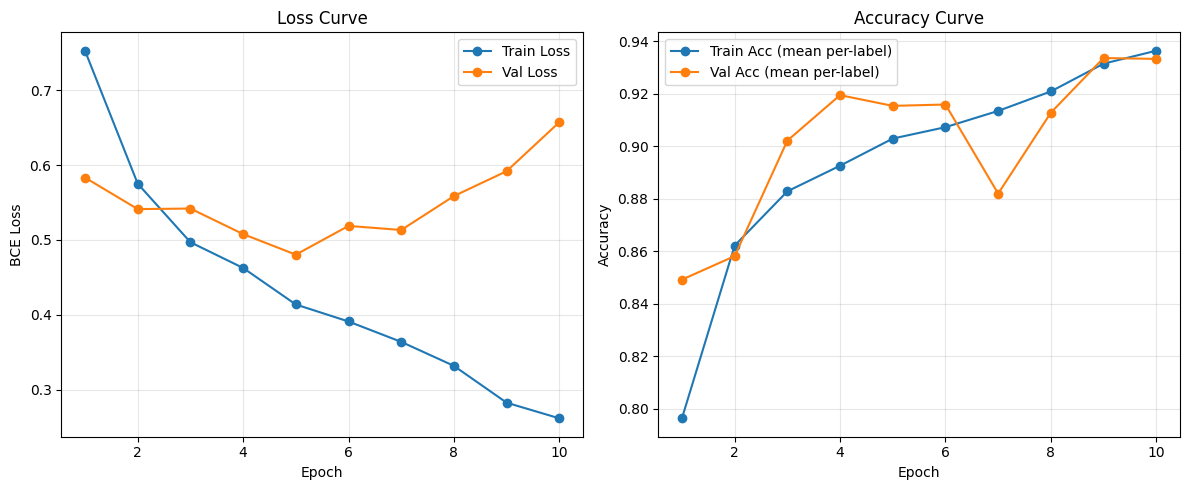


Classification Report (Validation Set):

                  precision    recall  f1-score   support

             any       0.66      0.90      0.76      1082
        epidural       0.04      0.71      0.07        24
intraparenchymal       0.43      0.92      0.58       361
intraventricular       0.35      0.97      0.52       272
    subarachnoid       0.27      0.91      0.41       361
        subdural       0.35      0.85      0.49       471

       micro avg       0.40      0.90      0.55      2571
       macro avg       0.35      0.88      0.47      2571
    weighted avg       0.48      0.90      0.61      2571
     samples avg       0.09      0.13      0.10      2571



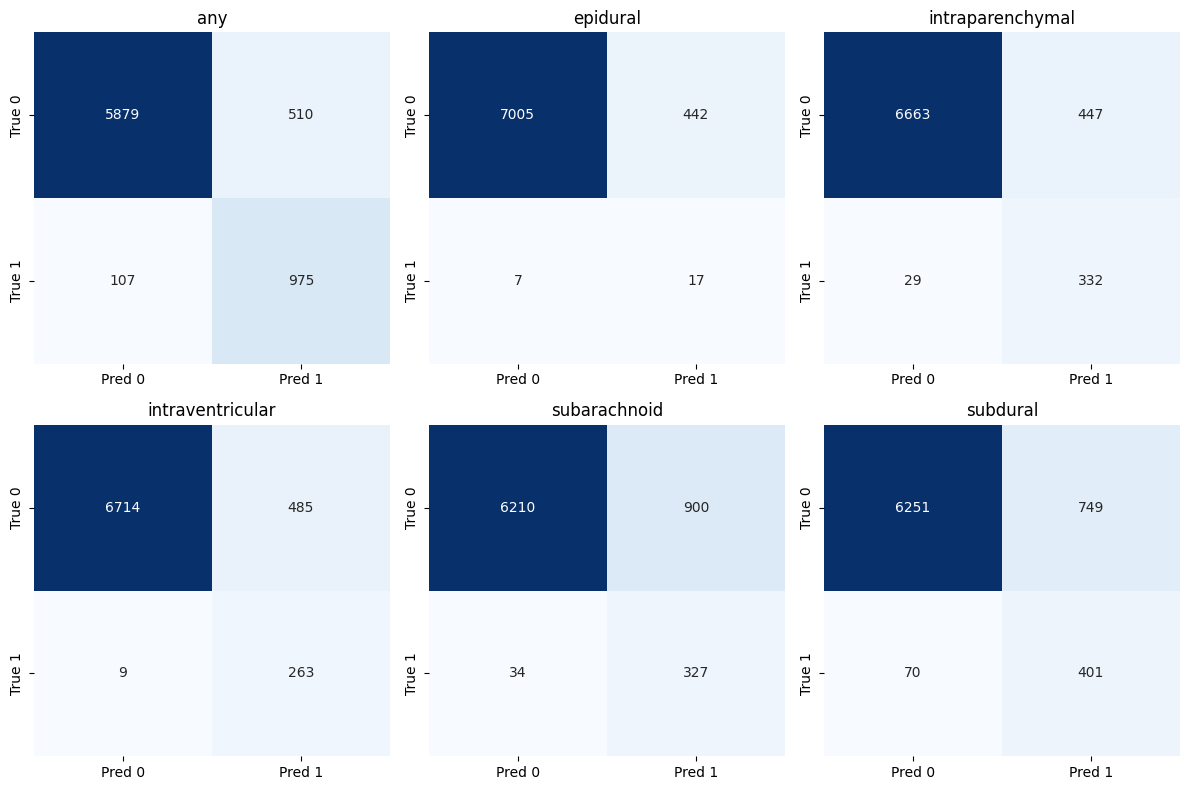


Training complete. Best val loss: 0.4804
Results saved to: /kaggle/working/results/
Best checkpoint saved to: /kaggle/working/checkpoints/best_model.pth


In [14]:
from train import main
main()